# Pose predictors

## File Handling
To run predictions a `RobotEnvironment` object and a `HeadsetData` object is needed, those can be loaded from folders or created.

### Creation of RobotEnvironment and HeadsetData
Those 2 datatypes can be created from an GatheredRobotData object and a .vrs file respectively.

In [1]:
%load_ext autoreload
%autoreload 2
print(__debug__)
from headset_data import *
from robot_environment import *

True


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
robot_data_folder_location = "/home/wmarx/AR-Headset-Localization-in-Robot-Scanned-Workspaces-A-Benchmark-Pipeline/datasets/r7_small_aruco4"
vrs_file_location = "/home/wmarx/AR-Headset-Localization-in-Robot-Scanned-Workspaces-A-Benchmark-Pipeline/datasets/r7_small_aruco4_20fps_close.vrs"


robot_data = GatheredRobotData.from_folder(robot_data_folder_location)
robot_env = RobotEnvironment.from_gathered_robot_data(
        robot_data = robot_data,
        number_of_sampled_datapoints=10,
        only_sample_robot_datapoints_w_marker_estimates = True,
        markers_use_advanced_removal=True,
        est3d_xyz_image_gen_config = XYZImageGenerationConfig(),
        est3d_xyz_icp_config=ICPAlignmentConfig()
)

labeled_headset_data = create_robot_bound_headset_data(
        headset_data = HeadsetData.from_vrs_file(vrs_file_location),
        robot_data = robot_data
)

visualize_loaded_data = True

if visualize_loaded_data:
    visualize_robot_camera_environment_combo(robot_env=robot_env, headset_data=labeled_headset_data)


length of chosen indices 10
Generating point cloud...
Loading pretrained dinov2_vitg14 from torch hub


Using cache found in /home/wmarx/.cache/torch/hub/facebookresearch_dinov2_main


image shape before processing: (10, 720, 720, 3)
xyz images shape: (10, 518, 518, 3)
aligning pointclouds using ICP


100%|██████████| 9/9 [00:45<00:00,  5.10s/it]
[ProgressLogger][INFO]: 2026-06-10 15:32:53: Opening /home/wmarx/AR-Headset-Localization-in-Robot-Scanned-Workspaces-A-Benchmark-Pipeline/datasets/r7_small_aruco4_20fps_close.vrs...
[TelemetryLogger][INFO]: RecordFileReader::doOpenFile, diskfile: success, 29224928
[VRSIndexRecord][WARNING]: 1 record(s) not sorted properly. Sorting index.
[MultiRecordFileReader][DEBUG]: Opened file '/home/wmarx/AR-Headset-Localization-in-Robot-Scanned-Workspaces-A-Benchmark-Pipeline/datasets/r7_small_aruco4_20fps_close.vrs' and assigned to reader #0
[VrsDataProvider][INFO]: streamId 214-1/camera-rgb activated
[VrsDataProvider][INFO]: streamId 247-1/baro0 activated
[VrsDataProvider][INFO]: streamId 281-1/gps activated
[VrsDataProvider][INFO]: streamId 282-1/wps activated
[VrsDataProvider][INFO]: streamId 283-1/bluetooth activated
[VrsDataProvider][INFO]: Utc stream found: 285-1
[VrsDataProvider][INFO]: Fail to activate streamId 286-1
[VrsDataProvider][INFO]: 

## Testing Predictors

In [3]:
from predictor_grader import *
from pose_pred_points import *
from pose_pred_points_ellipsoids import *

### Creating Predictors
Now an `PosePredictor` can be created. An `PosePredictor` instance is build upon an `RobotEnvironment` instance and can predict positions from headset-images.

In [4]:
#pne_optimizer = PyposePNEOptimizer(PyposePnEOptimizerConfig())
#pne_optimizer = PnEDeltaPoseLBFGSOptimizer(time_tracker=tt_pne)

predictor = EllipsoidPredictor(
        cam2_intrinsic_mtx=labeled_headset_data.intrinsic_cam_mtx,
        cam1_bgr_images=robot_env.robot_bgr_images,
        cam1_xyz_images=robot_env.robot_xyz_images,
        extract_and_match_wrapper_config=ExtractAndMatchWrapperConfig(
            rotation_augmentations=[Rotate180Deg],
            extract_and_match=ExtractAndLightGlue(),
            ransac_config=pose_estimation_ransaac_config_less_precise,
        ),
        pne_optimizer=PnEDeltaPoseAdamOptimizer(),
        ellipsoid_refinement_at_res=(1400, 1400),
        cam1_segmenter=SAM3Segmenter(Sam3Prompt()),
        cam2_segmenter=YOLOv26Segmenter("yoloe-26l-seg.pt"),
        matching_config=GaussianMatchingConfig(dummy_value=0.01),
        visualize_pne_optimisation=False
)

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

### Grading the Performance of an Initialised Predictor:

In [5]:
init_predictor_grade = PredictionOnDataset(
    predictor = predictor,
    headset_data = labeled_headset_data,
    number_retry = 1
)
init_predictor_grade.print_summary()


visualize_prediction = True
if visualize_prediction:
    init_predictor_grade.visualize_predictions(
        robot_env=robot_env,
        show_label=False
    )

  0%|          | 0/90 [00:00<?, ?it/s]

  1%|          | 1/90 [00:00<00:42,  2.08it/s]

optimize pne called: <class 'geometric_utilities.pne_delta_pose_otimizer.PnEDeltaPoseAdamOptimizer'>


  2%|▏         | 2/90 [00:00<00:31,  2.76it/s]

optimize pne called: <class 'geometric_utilities.pne_delta_pose_otimizer.PnEDeltaPoseAdamOptimizer'>


...

optimize pne called: <class 'geometric_utilities.pne_delta_pose_otimizer.PnEDeltaPoseAdamOptimizer'>


 99%|█████████▉| 89/90 [00:22<00:00,  3.71it/s]

optimize pne called: <class 'geometric_utilities.pne_delta_pose_otimizer.PnEDeltaPoseAdamOptimizer'>


100%|██████████| 90/90 [00:22<00:00,  3.95it/s]

optimize pne called: <class 'geometric_utilities.pne_delta_pose_otimizer.PnEDeltaPoseAdamOptimizer'>
Success rate: 0.9555555555555556 for 90 predictions
Avg. time per prediction: 262.89635504660913ms
est_base_t_cam subcomponent times:

PNE optimisation                         107.379 ms
Image to primal conics                   87.671 ms
Point based initial guess                62.542 ms
Matching the 2d gaussians                1.191 ms
Projecting the 3d ellipsoids to 2d Gauss 0.618 ms
Primal conics to gaussians               0.309 ms


Avg. error: 107.0mm and 9.2°
Median. error: 91.7mm and 7.7°
ATE RMSE: 124.7mm and 10.0°
RTE RMSE: 133.1mm and 10.1°


In [6]:
# Creation of the Predictors
light_glue = ExtractAndLightGlue()
yolo = YOLOv26Segmenter("yoloe-26l-seg.pt")


no_ellips = GradablePosePredictor(
    creator=OnlyPointsPredictor.get_creation_function(
        cam2_intrinsic_mtx=labeled_headset_data.intrinsic_cam_mtx,
        extract_and_match_wrapper_config=ExtractAndMatchWrapperConfig(
            rotation_augmentations=[Rotate180Deg],
            extract_and_match=light_glue,
            ransac_config=pose_estimation_ransaac_config_precise,
        )
    ),
    name="no ellipse"
)

ellips_adam = GradablePosePredictor(
    creator=EllipsoidPredictor.get_creation_function(
        cam2_intrinsic_mtx=labeled_headset_data.intrinsic_cam_mtx,
        extract_and_match_wrapper_config=ExtractAndMatchWrapperConfig(
            rotation_augmentations=[Rotate180Deg],
            extract_and_match=light_glue,
            ransac_config=pose_estimation_ransaac_config_less_precise,
        ),
        pne_optimizer=PnEDeltaPoseAdamOptimizer(PnEDeltaPoseAdamOptimizerConfig(learning_rate=0.005, max_itterations = 1000)),
        ellipsoid_refinement_at_res=(1400, 1400),
        cam1_segmenter=SAM3Segmenter(Sam3Prompt()),
        cam2_segmenter=yolo,
        matching_config=GaussianMatchingConfig(dummy_value=0.01),
        visualize_pne_optimisation=False
    ),
    name="ellips_adam"
)

ellips_pypose = GradablePosePredictor(
    creator=EllipsoidPredictor.get_creation_function(
        cam2_intrinsic_mtx=labeled_headset_data.intrinsic_cam_mtx,
        extract_and_match_wrapper_config=ExtractAndMatchWrapperConfig(
            rotation_augmentations=[Rotate180Deg],
            extract_and_match=light_glue,
            ransac_config=pose_estimation_ransaac_config_less_precise,
        ),
        pne_optimizer=PyposePNEOptimizer(),
        ellipsoid_refinement_at_res=(1400, 1400),
        cam1_segmenter=SAM3Segmenter(Sam3Prompt()),
        cam2_segmenter=yolo,
        matching_config=GaussianMatchingConfig(dummy_value=0.01),
        visualize_pne_optimisation=False
    ),
    name="ellips_pypose"
)

Now those can be used to create a grader object for multiple `PosePredictor` variants.

In [7]:
# Initialising the grader:
grader = NPredictors1DatasetGrader(
    gradable_pose_predictors=[no_ellips, ellips_adam, ellips_pypose],
    headset_data = labeled_headset_data,
    robot_env = robot_env,
)

  0%|          | 0/90 [00:00<?, ?it/s]

optimize pne called: <class 'geometric_utilities.pne_delta_pose_otimizer.PnEDeltaPoseAdamOptimizer'>


  1%|          | 1/90 [00:01<02:02,  1.37s/it]

optimize pne called: <class 'geometric_utilities.pne_delta_pose_otimizer.PnEDeltaPoseAdamOptimizer'>


  2%|▏         | 2/90 [00:02<01:52,  1.28s/it]

...

fd in optimize: None
optimize pne called: <class 'geometric_utilities.pypose_pne_optimizer.PyposePNEOptimizer'>
pypose optimize pne called


 99%|█████████▉| 89/90 [00:31<00:00,  2.85it/s]

fd in optimize: None
optimize pne called: <class 'geometric_utilities.pypose_pne_optimizer.PyposePNEOptimizer'>
pypose optimize pne called


100%|██████████| 90/90 [00:31<00:00,  2.87it/s]

fd in optimize: None


name                           success ratio %      T/frame [ms]    avg t_err [mm]  avg r_err [deg] med t_err [mm]  med r_err [deg]

no ellipse                     95.56                73              107.2           7.4            90.9            5.9            
ellips_adam                    95.56                1193            99.5            9.4            75.9            6.6            
ellips_pypose                  95.56                363             82.7            7.3            77.2            6.8            
rest: [    0.14777    0.089534    0.090498]


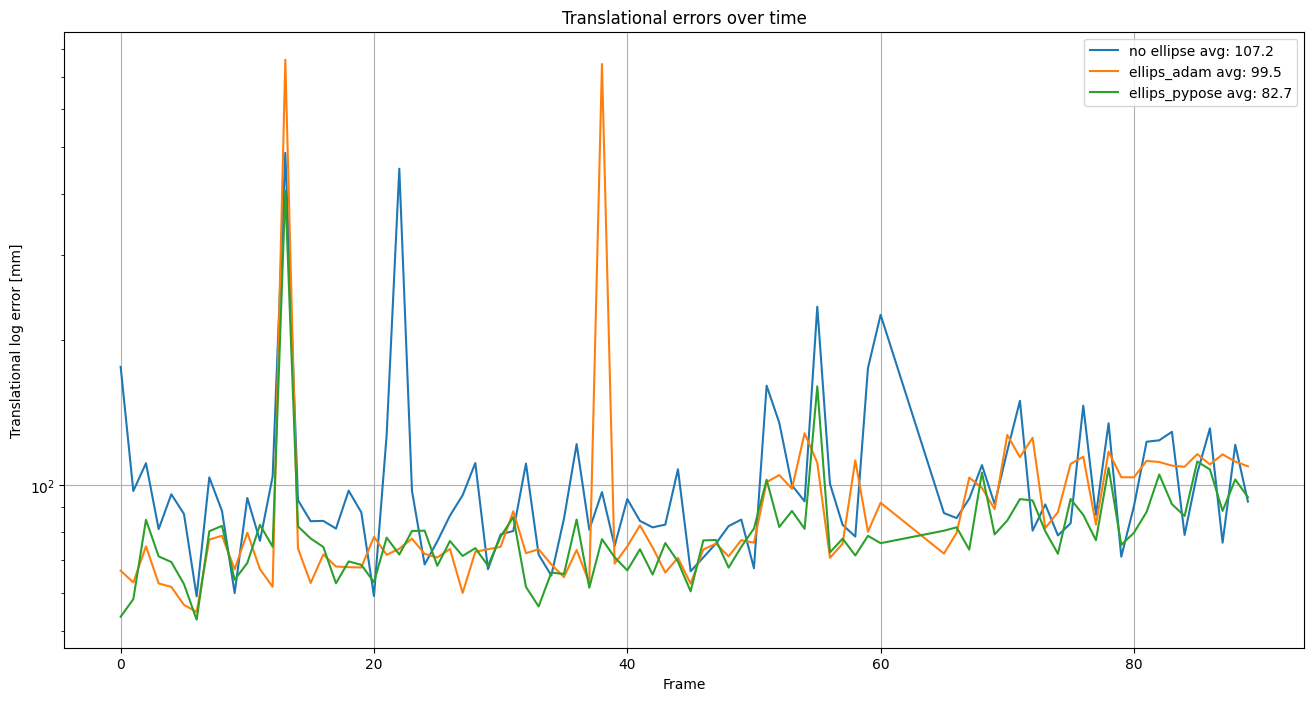

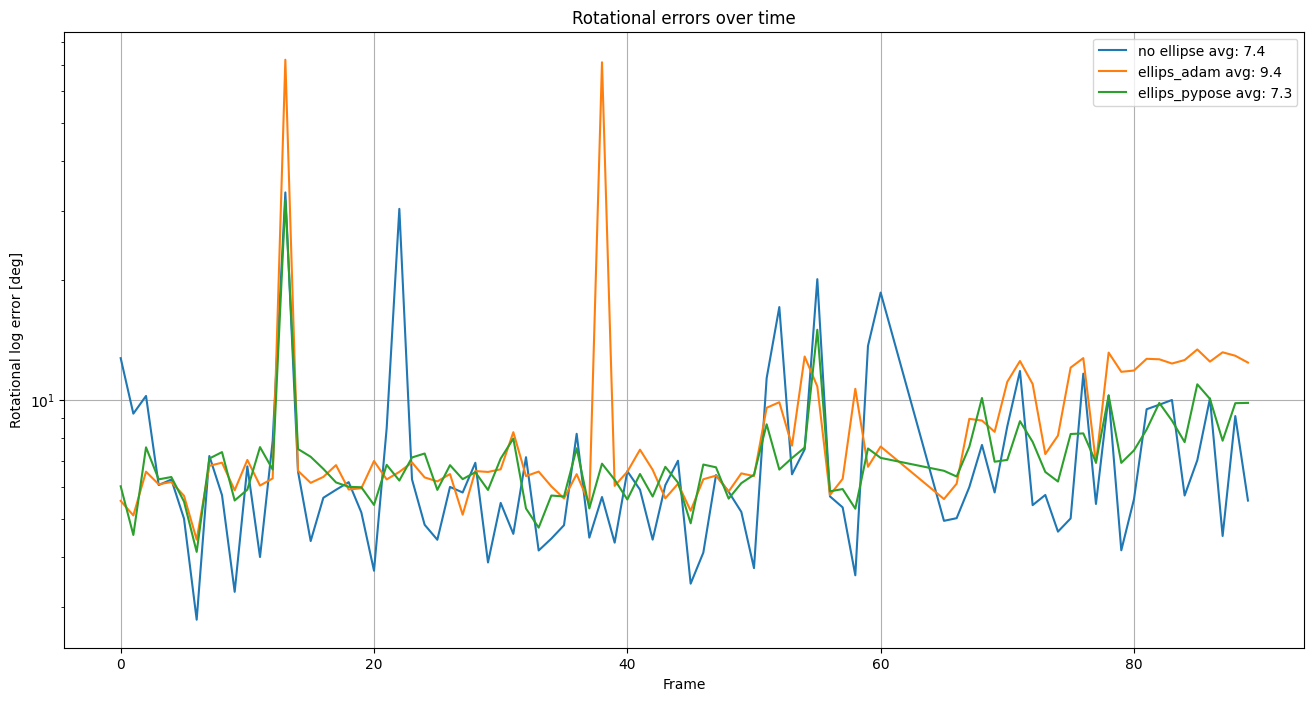

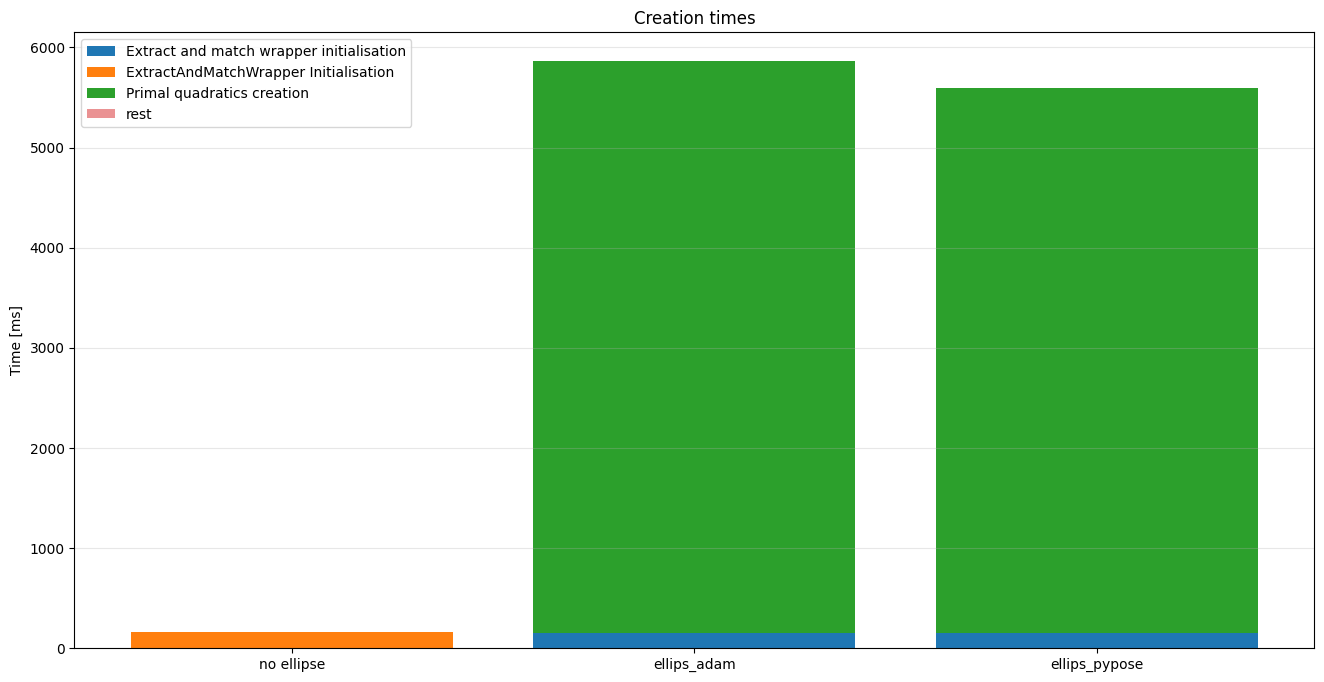

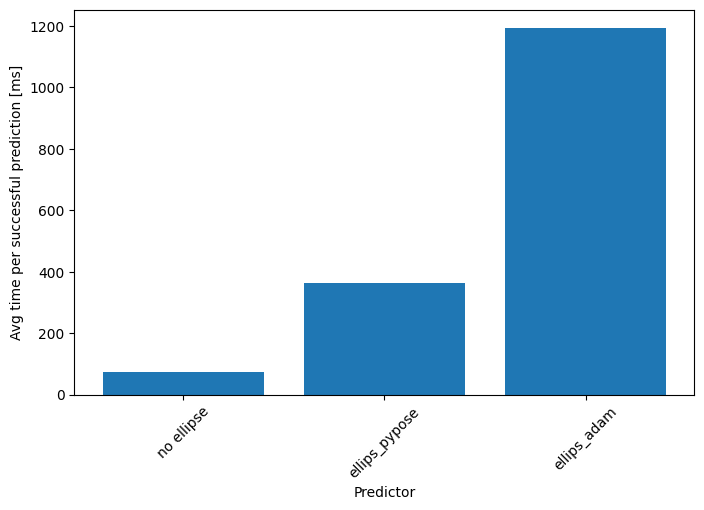

In [8]:
visualize_trajectories_3d = True
if visualize_trajectories_3d:
    grader.visualize_predictions_3d()

grader.print_summary()

fig1, ax1 = plt.subplots(1, 1, figsize = (16, 8))
grader.plot_translational_errors(ax1)

fig2, ax2 = plt.subplots(1, 1, figsize = (16, 8))
grader.plot_rotational_errors(ax2)

fig3, ax3 = plt.subplots(1, 1, figsize = (16, 8))
grader.plot_creation_times(ax3)

fig4, ax4 = plt.subplots(1, 1, figsize = (8, 5))
grader.plot_successful_frame_prediction_times(ax4)


plt.show()

### Visualising the Predictor in Video Format

In [20]:
from geometric_utilities.slam2mp4 import VideoGenerator

video_predictor = EllipsoidPredictor(
        cam2_intrinsic_mtx=labeled_headset_data.intrinsic_cam_mtx,
        cam1_bgr_images=robot_env.robot_bgr_images,
        cam1_xyz_images=robot_env.robot_xyz_images,
        extract_and_match_wrapper_config=ExtractAndMatchWrapperConfig(
            rotation_augmentations=[Rotate180Deg],
            extract_and_match=light_glue,
            ransac_config=pose_estimation_ransaac_config_less_precise,
        ),
        pne_optimizer=PyposePNEOptimizer(),
        ellipsoid_refinement_at_res=(1400, 1400),
        cam1_segmenter=SAM3Segmenter(Sam3Prompt()),
        cam2_segmenter=yolo,
        matching_config=GaussianMatchingConfig(dummy_value=0.01),
        visualize_pne_optimisation=False
)

init_predictor_grade = PredictionOnDataset(
    predictor = video_predictor,
    headset_data = labeled_headset_data,
    number_retry = 1,
    vid_gen=VideoGenerator(fps=20)
)
init_predictor_grade.print_summary()

100%|██████████| 90/90 [00:37<00:00,  2.38it/s]


Video saved to test.mp4
Success rate: 0.9555555555555556 for 90 predictions
Avg. time per prediction: 379.9707523742041ms
est_base_t_cam subcomponent times:

PNE optimisation                         199.482 ms
Image to primal conics                   87.268 ms
Point based initial guess                64.829 ms
Matching the 2d gaussians                1.198 ms
Projecting the 3d ellipsoids to 2d Gauss 0.559 ms
Primal conics to gaussians               0.315 ms


Avg. error: 81.8mm and 7.2°
Median. error: 75.2mm and 6.6°
ATE RMSE: 90.6mm and 8.0°
RTE RMSE: 81.5mm and 6.8°
